***PROYECTO INTELIGENCIA ARTIFICIAL IDENTIFICACIÓN DE BARNO-NO BARCO***

In [15]:
!unzip -q "/PROYECTO IA/shipsnet.zip" -d "/PROYECTO IA/"
print("¡Archivo descomprimido con éxito!")

¡Archivo descomprimido con éxito!


Buscando y cargando las imágenes automáticamente... (esto tomará unos segunditos)
✅ ¡Misterio resuelto! Datos cargados exitosamente.
   -> Tenemos 4000 imágenes de 80x80 con 3 canales de color.


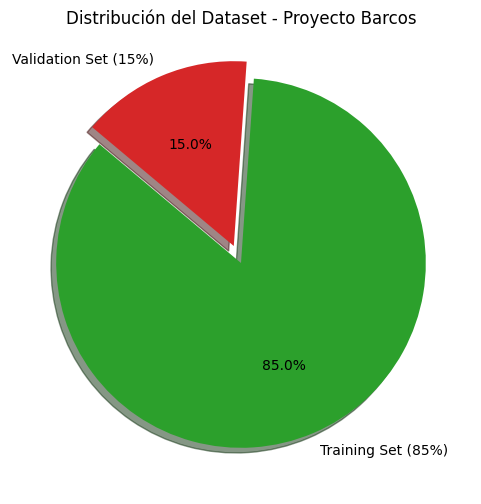

In [19]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

X = []
y = []

print("Buscando y cargando las imágenes automáticamente... (esto tomará unos segunditos)")

# 1. Este comando (os.walk) busca como un sabueso en todas las subcarpetas
directorio_base = '/PROYECTO IA/'
imagenes_encontradas = 0

for root, dirs, files in os.walk(directorio_base):
    for archivo in files:
        if archivo.endswith(".png"):
            # Encontramos un PNG, lo procesamos
            try:
                # La etiqueta es el primer caracter ('1' o '0')
                etiqueta = int(archivo[0])
                y.append(etiqueta)

                # Cargar la imagen
                ruta_imagen = os.path.join(root, archivo)
                imagen = cv2.imread(ruta_imagen)
                imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

                X.append(imagen)
                imagenes_encontradas += 1
            except ValueError:
                # Si hay algún PNG atravesado que no empieza con número, lo ignora
                pass

if imagenes_encontradas == 0:
    print("❌ ERROR: El buscador no encontró ni una sola imagen .png.")
    print("¿Estás seguro de que el .zip contenía las imágenes?")
else:
    # 2. Convertimos a Arrays de Numpy
    X = np.array(X)
    y = np.array(y)

    print(f"✅ ¡Misterio resuelto! Datos cargados exitosamente.")
    print(f"   -> Tenemos {X.shape[0]} imágenes de {X.shape[1]}x{X.shape[2]} con {X.shape[3]} canales de color.")

    # 3. Normalizar las imágenes (0 a 1)
    X = X / 255.0

    # ==========================================
    # EVIDENCIA: GRÁFICA DE PASTEL (85% - 15%)
    # ==========================================
    labels = ['Training Set (85%)', 'Validation Set (15%)']
    sizes = [85, 15]
    colors = ['#2ca02c', '#d62728']
    explode = (0, 0.1)

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
    plt.title("Distribución del Dataset - Proyecto Barcos")

    plt.savefig("grafica_pastel.png")
    plt.show()

In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. FUNCIÓN PARA CREAR LA RED NEURONAL (CNN)
# ==========================================
def crear_modelo():
    model = Sequential([
        # Capa 1: Extraer características básicas (bordes, colores)
        Conv2D(32, (3, 3), activation='relu', input_shape=(80, 80, 3)),
        MaxPooling2D(2, 2),

        # Capa 2: Extraer características más complejas (formas del barco)
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        # Capa 3: Mayor profundidad
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        # Aplanar la imagen y decidir
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # APAGA el 50% de las neuronas para evitar sobreajuste (Overfitting)
        Dense(1, activation='sigmoid') # Sigmoid porque es clasificación binaria (1 o 0)
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ==========================================
# 2. CONFIGURACIÓN DE LOS 5 FOLDS (85% - 15%)
# ==========================================
# Usamos StratifiedShuffleSplit para garantizar que en cada 85/15 siempre haya la misma proporción de barcos y no-barcos
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.15, random_state=42)

# Listas para guardar las métricas de cada fold
accuracies = []
precisions = []
recalls = []
f1_scores = []

mejor_accuracy = 0
fold_actual = 1

print("🚀 Iniciando Entrenamiento de 5 Folds...\n")

# ==========================================
# 3. BUCLE DE ENTRENAMIENTO CRUZADO
# ==========================================
for train_index, val_index in sss.split(X, y):
    print(f"--- FOLD {fold_actual} ---")

    # Separar los datos 85% entrenamiento y 15% validación
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Crear un modelo "limpio" para este fold
    modelo = crear_modelo()

    # Entrenar el modelo (10 epochs suele ser suficiente para este dataset)
    # verbose=0 oculta la barra de carga para no saturar la pantalla, pero imprimiremos el final
    historia = modelo.fit(X_train, y_train, epochs=10, batch_size=32,
                          validation_data=(X_val, y_val), verbose=0)

    # Predecir sobre el 15% de validación (probabilidades > 0.5 se vuelven 1, si no 0)
    y_pred_prob = modelo.predict(X_val, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calcular métricas
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    # Guardar para el promedio
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

    print(f"✅ Fold {fold_actual} completado -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")

    # Guardar el modelo si es el mejor hasta ahora
    if acc > mejor_accuracy:
        mejor_accuracy = acc
        modelo.save("mejor_modelo_barcos.h5")
        print("   🌟 ¡Nuevo mejor modelo guardado!")

    fold_actual += 1
    print("-" * 30)

# ==========================================
# 4. PROMEDIOS FINALES (EVIDENCIA)
# ==========================================
print("\n📊 RESULTADOS FINALES DE LA VALIDACIÓN CRUZADA (PROMEDIOS):")
print(f"   ➤ Accuracy Promedio:  {np.mean(accuracies):.4f} ({(np.mean(accuracies)*100):.2f}%)")
print(f"   ➤ Precision Promedio: {np.mean(precisions):.4f}")
print(f"   ➤ Recall Promedio:    {np.mean(recalls):.4f}")
print(f"   ➤ F1-Score Promedio:  {np.mean(f1_scores):.4f}")
print("\nEl modelo con el mejor desempeño ha sido guardado como 'mejor_modelo_barcos.h5'")

🚀 Iniciando Entrenamiento de 5 Folds...

--- FOLD 1 ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1 completado -> Accuracy: 0.9833 | Precision: 0.9861 | Recall: 0.9467
   🌟 ¡Nuevo mejor modelo guardado!
------------------------------
--- FOLD 2 ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 2 completado -> Accuracy: 0.9850 | Precision: 0.9796 | Recall: 0.9600
   🌟 ¡Nuevo mejor modelo guardado!
------------------------------
--- FOLD 3 ---


...

✅ Fold 3 completado -> Accuracy: 0.9783 | Precision: 0.9363 | Recall: 0.9800
------------------------------
--- FOLD 4 ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 4 completado -> Accuracy: 0.9800 | Precision: 0.9259 | Recall: 1.0000
------------------------------
--- FOLD 5 ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 5 completado -> Accuracy: 0.9817 | Precision: 0.9860 | Recall: 0.9400
------------------------------

📊 RESULTADOS FINALES DE LA VALIDACIÓN CRUZADA (PROMEDIOS):
   ➤ Accuracy Promedio:  0.9817 (98.17%)
   ➤ Precision Promedio: 0.9628
   ➤ Recall Promedio:    0.9653
   ➤ F1-Score Promedio:  0.9635

El modelo con el mejor desempeño ha sido guardado como 'mejor_modelo_barcos.h5'


Generando gráficas de evidencia para el documento Word...



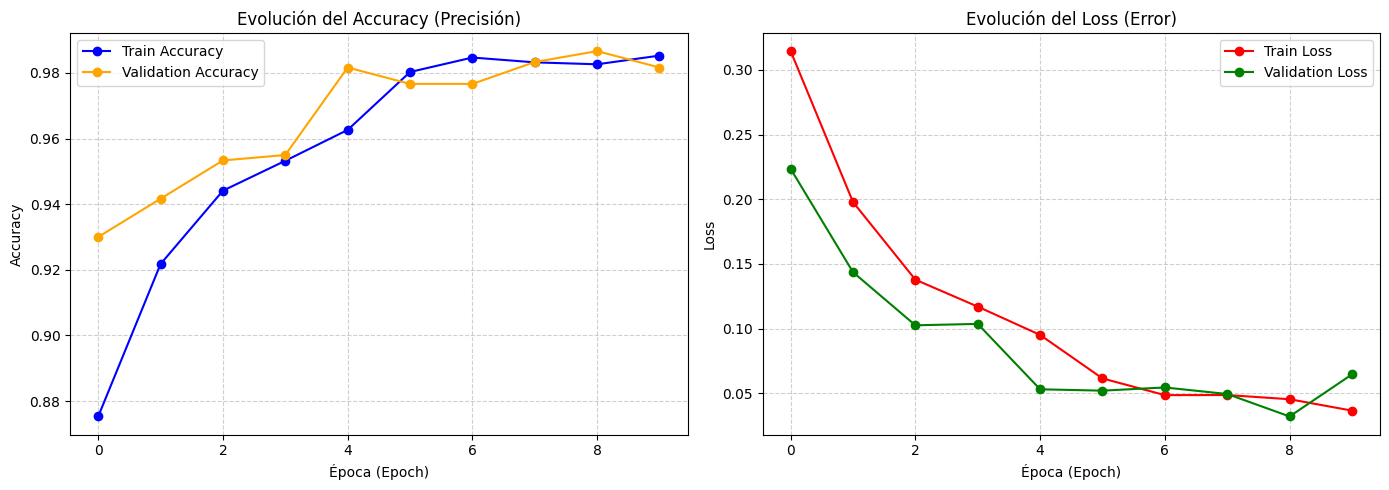

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


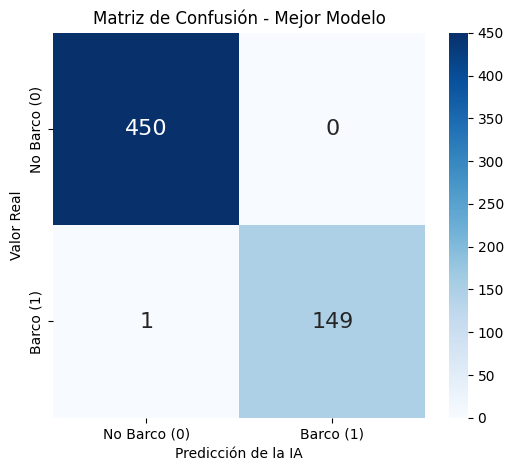

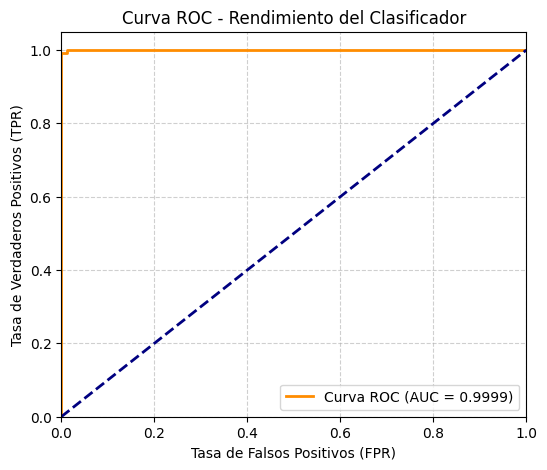

✅ ¡Gráficas generadas y guardadas exitosamente como imágenes (png)!
   Listas para ser pegadas en tu reporte.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model

print("Generando gráficas de evidencia para el documento Word...\n")

# ==========================================
# 1. CURVAS DE APRENDIZAJE (Del último fold)
# ==========================================
# Usamos la variable 'historia' que quedó guardada en el ciclo anterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Accuracy (Precisión)
ax1.plot(historia.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
ax1.plot(historia.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Evolución del Accuracy (Precisión)')
ax1.set_xlabel('Época (Epoch)')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Loss (Pérdida/Error)
ax2.plot(historia.history['loss'], label='Train Loss', color='red', marker='o')
ax2.plot(historia.history['val_loss'], label='Validation Loss', color='green', marker='o')
ax2.set_title('Evolución del Loss (Error)')
ax2.set_xlabel('Época (Epoch)')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("curvas_aprendizaje.png", dpi=300)
plt.show()

# ==========================================
# 2. CARGAR EL MEJOR MODELO PARA EVALUACIÓN
# ==========================================
# Cargamos el "cerebro" con la nota más alta que guardamos en el paso anterior
mejor_modelo = load_model('mejor_modelo_barcos.h5')

# Hacemos predicciones sobre el conjunto de validación del último fold
y_pred_prob = mejor_modelo.predict(X_val)
y_pred_clases = (y_pred_prob > 0.5).astype(int)

# ==========================================
# 3. MATRIZ DE CONFUSIÓN
# ==========================================
cm = confusion_matrix(y_val, y_pred_clases)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Barco (0)', 'Barco (1)'],
            yticklabels=['No Barco (0)', 'Barco (1)'],
            annot_kws={"size": 16})
plt.title('Matriz de Confusión - Mejor Modelo')
plt.xlabel('Predicción de la IA')
plt.ylabel('Valor Real')
plt.savefig("matriz_confusion.png", dpi=300)
plt.show()

# ==========================================
# 4. CURVA ROC Y AUC (Área bajo la curva)
# ==========================================
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Rendimiento del Clasificador')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("curva_roc.png", dpi=300)
plt.show()

print("✅ ¡Gráficas generadas y guardadas exitosamente como imágenes (png)!")
print("   Listas para ser pegadas en tu reporte.")

In [22]:
import os

print("Carpeta de trabajo actual:", os.getcwd())
print("¿El archivo existe?:", os.path.exists('mejor_modelo_barcos.h5'))

Carpeta de trabajo actual: /content
¿El archivo existe?: True
